Total Image Area: 2080000 pixels
Solid Tree Area (Including Open Areas): 175744 pixels
Blue Area (Openings): 30589 pixels
Blue Area as Percentage of Solid Tree Area: 17.40543062636562 %


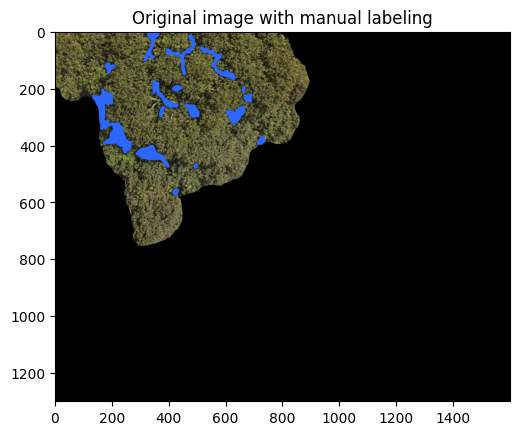

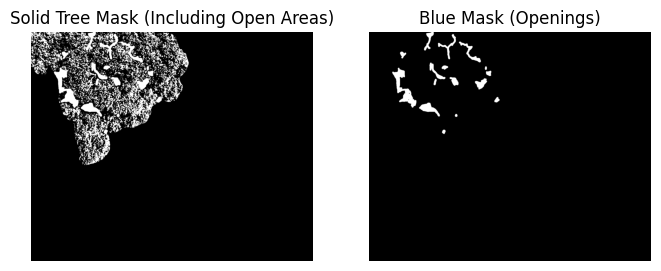

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

image_path = 'DJI_0030_mask_10 (1).png' 
image = Image.open(image_path).convert("RGB")  
image_array = np.array(image)

# Step 1: Create the total mask (tree area including openings)

background_threshold = 100  
background_mask = np.all(image_array < background_threshold, axis=-1)

# Create a solid tree mask that includes both tree and blue areas (ignoring near-black background)
solid_tree_mask = ~background_mask  

# Calculate the area of the solid tree mask (count of True pixels in the mask)
solid_tree_area = np.sum(solid_tree_mask)

# Step 2: Calculate the blue area within the mask

# Define the exact RGB values for blue color
blue_rgb = [44, 103, 255]

blue_mask = (image_array[:,:,0] == blue_rgb[0]) & \
            (image_array[:,:,1] == blue_rgb[1]) & \
            (image_array[:,:,2] == blue_rgb[2])

blue_area = np.sum(blue_mask)

# Step 3: Calculate the blue area as a percentage of the total solid tree area
blue_area_percentage = (blue_area / solid_tree_area) * 100 if solid_tree_area > 0 else 0

total_image_area = image_array.shape[0] * image_array.shape[1]

# Output the area results
print("Total Image Area:", total_image_area, "pixels")
print("Solid Tree Area (Including Open Areas):", solid_tree_area, "pixels")
print("Blue Area (Openings):", blue_area, "pixels")
print("Blue Area as Percentage of Solid Tree Area:", blue_area_percentage, "%")

plt.title("Original image with manual labeling")
plt.imshow(image)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.imshow(solid_tree_mask, cmap="gray")
plt.title("Solid Tree Mask (Including Open Areas)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blue_mask, cmap="gray")
plt.title("Blue Mask (Openings)")
plt.axis('off')
plt.show()
